<div style="
background-color:#EAEAEA;
padding:15px;
border-left:5px solid #6C757D;
border-radius:6px;">

# Master's Thesis in Advanced Physics
---

This notebook is part of the **Master's Thesis (MSc Dissertation)**: **Fast Simulation of Neutrino Oscillations in Matter**.

**Author**
Juan Ramon Diaz Santos <diazjuan@alumni.uv.es>

**Supervisors**
Roberto Ruiz de Austri Bazan <rruiz@ific.uv.es>
Michele Lucente <michele.lucente@unibo.it>

**Date**
June 2026
</div>

# Validation NuSQuIDS 0: Summary
---

This notebook aggregates the precision-validation results produced by notebooks 1–3 and presents a compact equivalence dashboard between TPeanuts and nuSQuIDS across vacuum oscillations, solar neutrino propagation, solar-neutrino Earth detection, and atmospheric neutrino propagation. Run notebooks 1–3 first to generate the required CSV files.

Comparison data is available only when nuSQuIDS is installed. When it is not, comparison CSV files are not written by the child notebooks and this summary reports the availability status gracefully.

> **Note on solar (vn2):** The solar notebook now exports `vn2_solar_comparison.csv`, combining single-point and source-averaged $P_{ee}$ comparisons in the same summary-friendly format (`max_abs_err`, `max_rel_err`).

> **Note on Earth detection (vn4):** The Earth-detection notebook exports `vn4_earth_detection_comparison.csv`, combining fixed-angle probability, annual detector probability, benchmark detector flux/rate, and annual-count comparisons.

## Table of Contents

| § | Title |
|---|-------|
| [1](#1.-Libraries) | **Libraries** |
| [2](#2.-Paths-and-Configuration) | **Paths and Configuration** |
| [3](#3.-Load-Comparison-CSVs) | **Load Comparison CSVs** — discover `*_comparison.csv` per notebook |
| [4](#4.-Global-Aggregation) | **Global Aggregation** — worst-case and typical errors per medium |
| [5](#5.-Visualisation-and-Export) | **Visualisation and Export** — bar chart and CSV exports |

## 1. Libraries

In [11]:
from __future__ import annotations

%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from tpeanuts.notebooks.notebookConfig import load_notebook_config
from tpeanuts.notebooks.notebooks_helper import (
    TOL_PPB,
    TOL_PPM,
    save_and_show,
    status_from_rel,
)

from tpeanuts.external.nusquids.core import is_available as nusquids_is_available


## 2. Paths and Configuration

`load_notebook_config()` resolves the repository root and the shared output directory. All CSV files from notebooks 1–3 are written to the same flat directory `validation/nusquids/`. This notebook reads from that directory and writes its own exports to a `summary/` subdirectory inside it.

| Notebook | Prefix | Medium |
|----------|--------|--------|
| nusquids1 | `vn1_` | vacuum |
| nusquids2 | `vn2_` | solar |
| nusquids4 | `vn4_` | solar_earth_detection |
| nusquids3 | `vn3_` | atmosphere |

In [17]:
config          = load_notebook_config()
VALIDATION_ROOT = config.output_dir("validation", "nusquids")
OUTPUT_DIR      = VALIDATION_ROOT / "summary"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
SHOW_PLOTS      = config.show_plots

PREFIX_TO_MEDIUM = {
    "vn1_": "vacuum",
    "vn2_": "solar",
    "vn3_": "atmosphere",
    "vn4_": "solar_earth_detection",
    "vn5_": "solar_earth_detection",
}

print(f"Validation root : {VALIDATION_ROOT}")
print(f"Output dir      : {OUTPUT_DIR}")
print(f"nuSQuIDS available: {nusquids_is_available()}")


Validation root : /mnt/v/output/validation/nusquids
Output dir      : /mnt/v/output/validation/nusquids/summary
nuSQuIDS available: True


## 3. Load Comparison CSVs

Discovers all `*_comparison.csv` files in the validation directory. These files are produced by `compare_probability_grids` in notebooks 1 and 3 and contain `max_abs_err` / `max_rel_err` columns for each grid point. Files are grouped by their filename prefix (`vn1_` → vacuum, `vn3_` → atmosphere).

When nuSQuIDS is not installed, the comparison CSV files are not written and this section reports zero rows found.

In [18]:
summary_rows = []
for path in sorted(VALIDATION_ROOT.glob("*_comparison.csv")):
    medium = "unknown"
    for prefix, label in PREFIX_TO_MEDIUM.items():
        if path.name.startswith(prefix):
            medium = label
            break
    df = pd.read_csv(path)
    if {"max_abs_err", "max_rel_err"}.issubset(df.columns):
        max_abs = df["max_abs_err"].max()
        med_abs = df["max_abs_err"].median()
        max_rel = df["max_rel_err"].max()
        med_rel = df["max_rel_err"].median()
        summary_rows.append({
            "medium":         medium,
            "file":           path.name,
            "rows":           len(df),
            "max_abs_err":    max_abs,
            "median_abs_err": med_abs,
            "max_rel_err":    max_rel,
            "median_rel_err": med_rel,
            "status":         status_from_rel(max_rel),
        })

summary = pd.DataFrame(summary_rows)

if summary.empty:
    print("No comparison CSVs found. Run nusquids1, nusquids2, nusquids3, nusquids4, and nusquids5 notebooks first.")
    print(f"(nuSQuIDS available: {nusquids_is_available()})")
else:
    display(summary.sort_values(["medium", "max_rel_err"], ascending=[True, False]))


,medium,file,rows,max_abs_err,median_abs_err,max_rel_err,median_rel_err,status
2,atmosphere,vn3_atmosphere_comparison.csv,108,8.139075e-09,2.529088e-13,1.890274e-07,4.928187e-10,PASS < ppm
1,solar,vn2_solar_comparison.csv,208,2.136307e-03,5.556942e-04,5.381429e-03,1.693368e-03,CHECK
3,solar_earth_detection,vn5_earth_comparison.csv,3,5.585893e-03,4.779798e-03,1.847780e-02,1.403345e-02,CHECK
0,vacuum,vn1_vacuum_comparison.csv,108,2.436853e-09,3.618328e-12,1.704316e-08,1.574698e-10,PASS < ppm


## 4. Global Aggregation

Groups the per-file summary by medium and reports the overall worst-case and typical errors for each propagation stage. The `status` column is set by `status_from_rel`: `PASS < ppb` (< 10⁻⁹), `PASS < ppm` (< 10⁻⁶), `CHECK < 1e-3` (< 10⁻³), or `FAIL` otherwise.

**Expected results:** When nuSQuIDS is installed, both vacuum and atmosphere should show `PASS < ppb` or better, since both backends use identical physics parameters and the same density model.

In [19]:
if not summary.empty:
    global_summary = summary.groupby("medium", as_index=False).agg(
        files=("file", "count"),
        rows=("rows", "sum"),
        max_abs_err=("max_abs_err", "max"),
        median_abs_err=("median_abs_err", "median"),
        max_rel_err=("max_rel_err", "max"),
        median_rel_err=("median_rel_err", "median"),
    )
    global_summary["status"] = global_summary["max_rel_err"].map(status_from_rel)
    display(global_summary.sort_values("max_rel_err", ascending=False))
else:
    global_summary = pd.DataFrame()
    print("No data available for aggregation.")


,medium,files,rows,max_abs_err,median_abs_err,max_rel_err,median_rel_err,status
2,solar_earth_detection,1,3,5.585893e-03,4.779798e-03,1.847780e-02,1.403345e-02,CHECK
1,solar,1,208,2.136307e-03,5.556942e-04,5.381429e-03,1.693368e-03,CHECK
0,atmosphere,1,108,8.139075e-09,2.529088e-13,1.890274e-07,4.928187e-10,PASS < ppm
3,vacuum,1,108,2.436853e-09,3.618328e-12,1.704316e-08,1.574698e-10,PASS < ppm


## 5. Visualisation and Export

Two-panel bar chart comparing maximum absolute and relative errors across all validated media on a logarithmic scale. Horizontal reference lines mark the 1 ppm (10⁻⁶) and 1 ppb (10⁻⁹) tolerance levels. The chart provides an at-a-glance audit of the TPeanuts–nuSQuIDS equivalence.

Two aggregate CSV files are exported:

- `vn0_file_summary.csv` — one row per comparison CSV with per-file precision metrics.
- `vn0_global_summary.csv` — one row per medium with aggregate worst-case and typical metrics.

**Expected results:** When nuSQuIDS is installed, vacuum and atmosphere bars should sit at or below the 1 ppb line, solar Earth-detection should typically track the Earth-stage numerical agreement, and solar propagation typically reflects the known model mismatch plus the adiabatic-versus-coherent approximation difference. When nuSQuIDS is not available, the plot is skipped and a status message is shown.

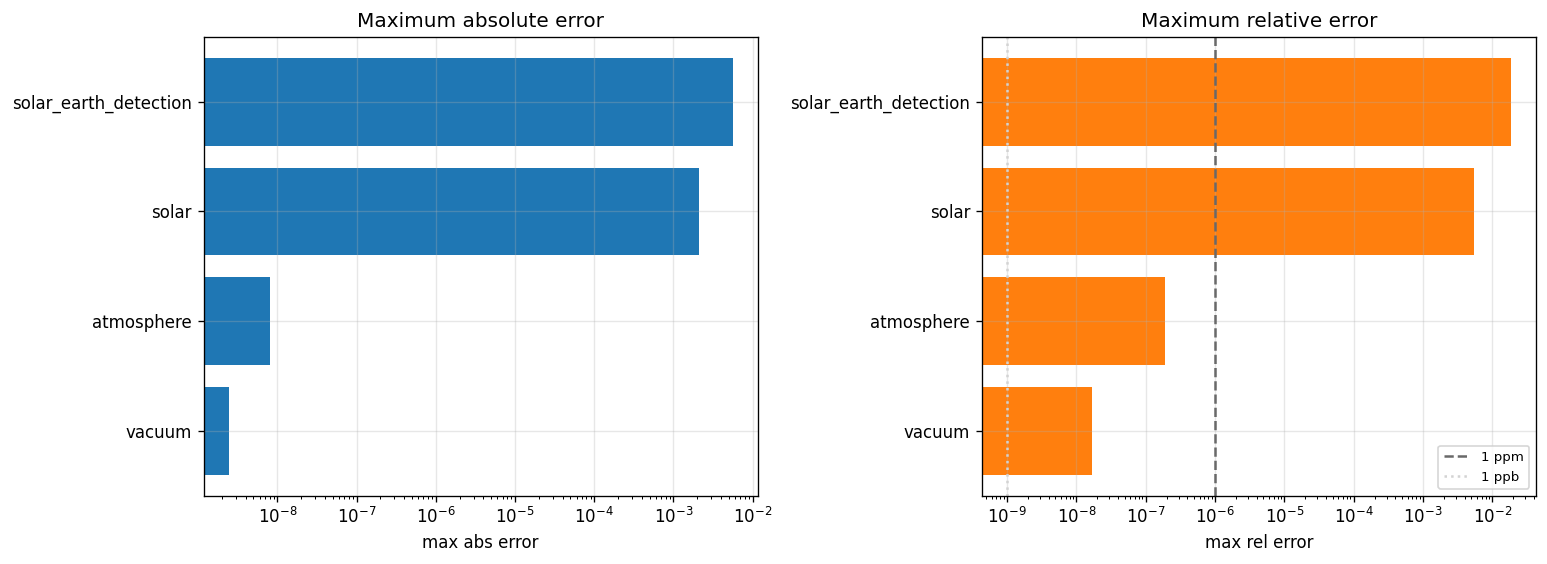

/mnt/v/output/validation/nusquids/summary/vn0_summary.png
Exported vn0_file_summary.csv and vn0_global_summary.csv


In [20]:
if not global_summary.empty and not global_summary["max_rel_err"].isna().all():
    fig, axes = plt.subplots(1, 2, figsize=(13.0, 4.8))
    ordered = global_summary.sort_values("max_rel_err", ascending=True)
    axes[0].barh(ordered["medium"], ordered["max_abs_err"], color="C0")
    axes[0].set_xscale("log")
    axes[0].set_xlabel("max abs error")
    axes[0].set_title("Maximum absolute error")
    axes[1].barh(ordered["medium"], ordered["max_rel_err"], color="C1")
    axes[1].set_xscale("log")
    axes[1].axvline(TOL_PPM, color="dimgray", ls="--", label="1 ppm")
    axes[1].axvline(TOL_PPB, color="lightgray", ls=":",  label="1 ppb")
    axes[1].set_xlabel("max rel error")
    axes[1].set_title("Maximum relative error")
    axes[1].legend(fontsize=8)
    fig.tight_layout()
    save_and_show("vn0_summary.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)
    summary.to_csv(OUTPUT_DIR / "vn0_file_summary.csv", index=False)
    global_summary.to_csv(OUTPUT_DIR / "vn0_global_summary.csv", index=False)
    print("Exported vn0_file_summary.csv and vn0_global_summary.csv")
elif not global_summary.empty:
    print("nuSQuIDS not available — all comparison values are NaN.")
    print("Install nuSQuIDS and re-run notebooks 1, 2, 3, 4, and 5 to generate comparison data.")
    summary.to_csv(OUTPUT_DIR / "vn0_file_summary.csv", index=False)
    global_summary.to_csv(OUTPUT_DIR / "vn0_global_summary.csv", index=False)
    print("Exported summary tables (comparison columns will contain NaN).")
else:
    print("No comparison CSV files found. Run nusquids1, nusquids2, nusquids3, nusquids4, and nusquids5 first.")
